In [118]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=df = pd.read_csv("retail_sales_dataset.csv") 
df


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [119]:
print("First Five rows")
df.head

First Five rows


<bound method NDFrame.head of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  

SHAPE OF DATASET



In [120]:
print("\nShape of the dataset:")
print(df.shape)


Shape of the dataset:
(1000, 9)


In [121]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')


DATATYPES OF EACH COLUMN


In [122]:
print(df.dtypes)

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


In [123]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB
None


In [124]:
print("\nNull Values")
print(df.isnull().sum())



Null Values
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [125]:
numerical_cols = df.select_dtypes(include='number')
numerical_cols

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,34,3,50,150
1,2,26,2,500,1000
2,3,50,1,30,30
3,4,37,1,500,500
4,5,30,2,50,100
...,...,...,...,...,...
995,996,62,1,50,50
996,997,52,3,30,90
997,998,23,4,25,100
998,999,36,3,50,150


In [126]:
print("Mean,Median,Min,Max")
df.describe()

Mean,Median,Min,Max


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [127]:
df['Revenue'] = df['Quantity'] * df['Price per Unit']
df['Date'] = pd.to_datetime(df['Date'])

Monthly sales

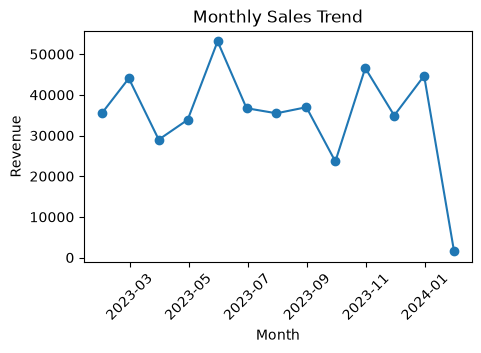

In [128]:
monthly_sales = df.set_index('Date')['Revenue'].resample('ME').sum()

plt.figure(figsize=(5,3))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

The monthly sales trend shows how revenue changes over time. Peaks indicate months with higher sales, while declines may indicate periods of lower customer demand

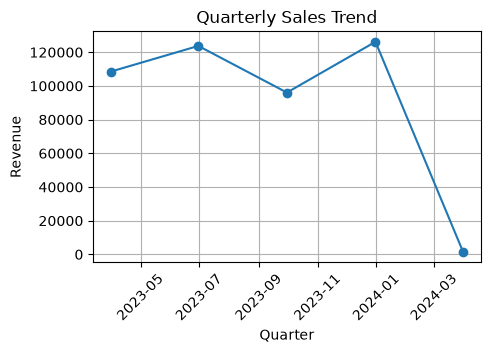

In [129]:
quarterly_sales = df.set_index('Date')['Revenue'].resample('QE').sum()

plt.figure(figsize=(5,3))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [130]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Revenue'],
      dtype='str')

In [131]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

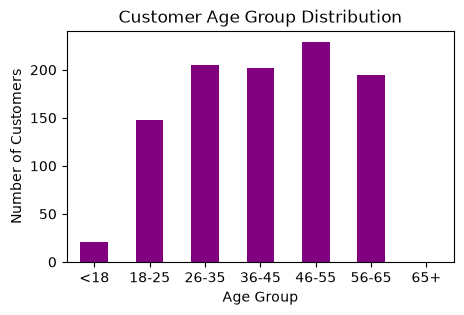

In [132]:
plt.figure(figsize=(5,3))

df['AgeGroup'].value_counts().sort_index().plot(kind='bar',color='purple')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

The gender distribution shows the proportion of customers across different gender categories. This information can help the business understand its customer base and design more targeted marketing campaigns.


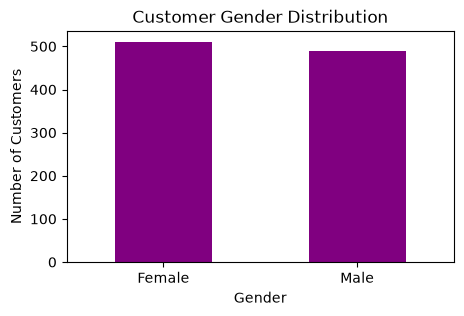

In [133]:
plt.figure(figsize=(5,3))

df['Gender'].value_counts().plot(kind='bar',color='purple')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

The gender distribution shows the proportion of customers across different gender categories. This information can help the business understand its customer base and design more targeted marketing campaigns.

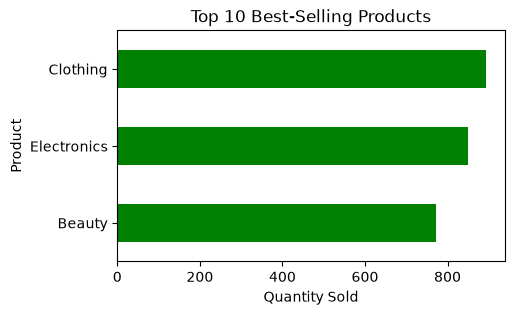

In [134]:
top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10))

plt.figure(figsize=(5,3))
top_products.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

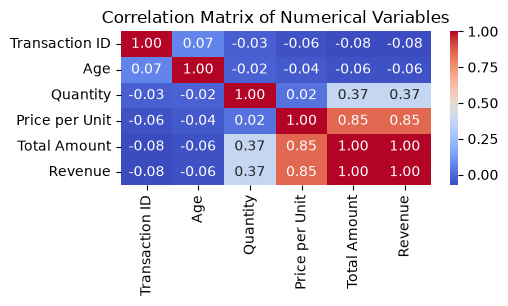

In [139]:
numerical_cols = df.select_dtypes(include='number')

correlation = numerical_cols.corr()

plt.figure(figsize=(5,2))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


The correlation matrix shows the relationships between numerical variables. Strong positive or negative correlations indicate that two variables tend to change together, while values close to zero indicate a weak linear relationship.

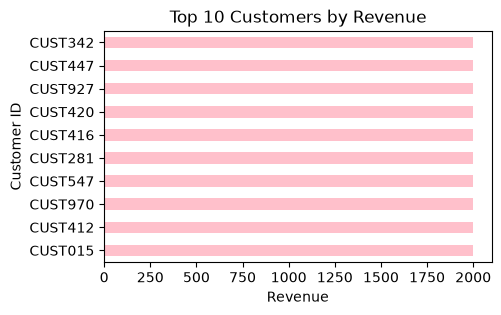

In [144]:
top_customers = (
    df.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(5,3))
top_customers.sort_values().plot(kind='barh',color='pink')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.show()

# Conclusion

The exploratory data analysis provided insights into sales trends, customer behavior, product performance, and relationships between numerical variables.

### Business Recommendations

1. **Focus on high-performing products:** 
   The company should maintain sufficient inventory for the top-selling products to avoid stockouts and maximize sales opportunities.

2. **Use seasonal sales patterns:**
   Months and quarters with higher revenue can be targeted with promotional campaigns and increased inventory planning.

3. **Retain high-value customers:**
   Customers generating significant revenue should be targeted with loyalty programs, personalized offers, and exclusive promotions.

4. **Improve product strategy:**
   Products with high sales volume but relatively low revenue can be reviewed for pricing and upselling opportunities.

5. **Target major customer markets:**
   Countries with a high number of customers can receive focused marketing campaigns and localized promotions.